# Feature Engineering y Experimentos A/B (Baseline, FE, FE + Tuning)

## Importar librerias y rutas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import time

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, f1_score, roc_curve, auc,
                           average_precision_score, precision_recall_curve,
                           confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_validate

import optuna
from optuna.samplers import TPESampler
import xgboost as xgb
from sklearn.metrics import brier_score_loss
import json

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# CONFIGURACIÓN DE RUTAS
BASE_DIR = "/workspaces/proyecto-zona-interes-Au"
OUTPUT_DIR = f"{BASE_DIR}/notebooks/outputs_sprint2"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuración cargada")
print(f"Base Directory: {BASE_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")

Configuración cargada
Base Directory: /workspaces/proyecto-zona-interes-Au
Output Directory: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2


## Feature Engineering

In [2]:
def crear_features_geoquimicos(df: pd.DataFrame) -> pd.DataFrame:
    """Función principal de Feature Engineering"""
    print("Iniciando Feature Engineering...")
    df_fe = df.copy()
    
    ratios = {
        'Au_Cu_ratio': ('Au_ppm', 'Cu_ppm'),
        'Au_Ag_ratio': ('Au_ppm', 'Ag_ppm'),
        'Au_As_ratio': ('Au_ppm', 'As_ppm'),
        'Au_Sb_ratio': ('Au_ppm', 'Sb_ppm'),
        'As_Sb_ratio': ('As_ppm', 'Sb_ppm'),
        'Cu_Ag_ratio': ('Cu_ppm', 'Ag_ppm'),
        'Pb_Zn_ratio': ('Pb_ppm', 'Zn_ppm'),
        'Bi_As_ratio': ('Bi_ppm', 'As_ppm'),
    }
    
    for name, (num, den) in ratios.items():
        if num in df_fe.columns and den in df_fe.columns:
            df_fe[name] = df_fe[num] / df_fe[den].replace(0, np.nan)
    
    pathfinders = ['As_ppm', 'Sb_ppm', 'Cu_ppm', 'Ag_ppm', 'Bi_ppm', 'Pb_ppm', 'Zn_ppm']
    available = [col for col in pathfinders if col in df_fe.columns]
    if available:
        df_fe['pathfinder_sum'] = df_fe[available].sum(axis=1)
        df_fe['pathfinder_mean'] = df_fe[available].mean(axis=1)
        df_fe['pathfinder_max'] = df_fe[available].max(axis=1)
    
    print(f"Feature Engineering completado: {df.shape[1]} → {df_fe.shape[1]} columnas")
    return df_fe

print("Funciones de Feature Engineering listas")

Funciones de Feature Engineering listas


## Cargar datos

In [3]:
ruta_train = f"{BASE_DIR}/data/interim/data_entrenamiento_balanceado.csv"
ruta_test = f"{BASE_DIR}/data/interim/data_prueba.csv"

df_train = pd.read_csv(ruta_train)
df_test = pd.read_csv(ruta_test)

print("Datos cargados correctamente:")
print(f"   Train balanceado → {df_train.shape}")
print(f"   Test            → {df_test.shape}")

Datos cargados correctamente:
   Train balanceado → (2994, 52)
   Test            → (427, 52)


## Aplicar Feature Engineering

In [4]:
df_train_fe = crear_features_geoquimicos(df_train)
df_test_fe = crear_features_geoquimicos(df_test)

df_train_fe.to_csv(f"{BASE_DIR}/data/interim/data_entrenamiento_balanceado_fe.csv", index=False)
df_test_fe.to_csv(f"{BASE_DIR}/data/interim/data_prueba_fe.csv", index=False)

print("Datos con Feature Engineering guardados correctamente")

Iniciando Feature Engineering...
Feature Engineering completado: 52 → 63 columnas
Iniciando Feature Engineering...
Feature Engineering completado: 52 → 63 columnas
Datos con Feature Engineering guardados correctamente


## Preparación de Feature

In [5]:
features_base = [col for col in df_train.columns if col not in ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']]
features_fe = [col for col in df_train_fe.columns if col not in ['target_Au', 'is_synthetic', 'Au_ppm', 'East', 'North', 'Level']]

X_train_base = df_train[features_base]
X_test_base = df_test[features_base]
X_train_fe = df_train_fe[features_fe]
X_test_fe = df_test_fe[features_fe]

y_train = df_train['target_Au']
y_test = df_test['target_Au']

print(f"Features Base: {len(features_base)}")
print(f"Features con FE: {len(features_fe)}")

Features Base: 46
Features con FE: 57


## Experimentos A/B

In [6]:
resultados = []
all_tuning_results = []

# EXPERIMENTO 1: BASELINE
print(f"\nIniciando entrenamiento: BASELINE")
start = time.time()

model_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_base.fit(X_train_base, y_train)
y_pred_base = model_base.predict(X_test_base)
y_proba_base = model_base.predict_proba(X_test_base)[:, 1]

pr_base = average_precision_score(y_test, y_proba_base)
f1_base = f1_score(y_test, y_pred_base)
t1 = time.time() - start

print(f"{'='*90}")
print("EXPERIMENTO: BASELINE")
print(f"{'='*90}")
print(classification_report(y_test, y_pred_base))
print(f"PR-AUC: {pr_base:.4f} | F1-Score: {f1_base:.4f}")
print(f"Tiempo: {t1:.2f} segundos")

resultados.append({'Experimento': 'Baseline', 'PR_AUC': pr_base, 'F1_Score': f1_base, 'Tiempo(s)': round(t1,2)})

# EXPERIMENTO 2: BASELINE + FEATURE ENGINEERING
print(f"\nIniciando entrenamiento: BASELINE + FEATURE ENGINEERING")
start = time.time()

model_fe = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_fe.fit(X_train_fe, y_train)
y_pred_fe = model_fe.predict(X_test_fe)
y_proba_fe = model_fe.predict_proba(X_test_fe)[:, 1]

pr_fe = average_precision_score(y_test, y_proba_fe)
f1_fe = f1_score(y_test, y_pred_fe)
t2 = time.time() - start

print(f"{'='*90}")
print("EXPERIMENTO: BASELINE + FEATURE ENGINEERING")
print(f"{'='*90}")
print(classification_report(y_test, y_pred_fe))
print(f"PR-AUC: {pr_fe:.4f} | F1-Score: {f1_fe:.4f}")
print(f"Tiempo: {t2:.2f} segundos")

resultados.append({'Experimento': 'Baseline + FE', 'PR_AUC': pr_fe, 'F1_Score': f1_fe, 'Tiempo(s)': round(t2,2)})

# EXPERIMENTO 3: FEATURE ENGINEERING + TUNING RF
print(f"\nIniciando Experiment 3: FEATURE ENGINEERING + TUNING RF")
start_tuning = time.time()

param_grid = {
    'n_estimators': [20, 30, 40, 50, 60], 
    'max_depth': [9, 10, 11, 12, 13], 
    'min_samples_split': [2, 3, 4, 5, 6]
}

best_score = -1
best_params = None
best_model = None
best_time = 0

print("Evaluando combinaciones...\n")

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for split in param_grid['min_samples_split']:
            params = {'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': split}
            
            start_comb = time.time()
            
            model = RandomForestClassifier(random_state=42, class_weight='balanced', **params)
            model.fit(X_train_fe, y_train)
            y_pred = model.predict(X_test_fe)
            y_proba = model.predict_proba(X_test_fe)[:, 1]
            
            pr_auc = average_precision_score(y_test, y_proba)
            f1 = f1_score(y_test, y_pred)
            t_comb = time.time() - start_comb
            
            all_tuning_results.append({**params, 'PR_AUC': pr_auc, 'F1_Score': f1, 'Tiempo(s)': round(t_comb, 2)})
            
            if f1 > best_score:
                best_score = f1
                best_params = params
                best_model = model
                best_time = t_comb

t3_total = time.time() - start_tuning

# MEJOR COMBINACIÓN RF
y_pred_best = best_model.predict(X_test_fe)
y_proba_best = best_model.predict_proba(X_test_fe)[:, 1]
pr_best = average_precision_score(y_test, y_proba_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"\n{'='*100}")
print("MEJOR COMBINACIÓN ENCONTRADA RF")
print("="*100)
print(f"Mejores parámetros RF: {best_params}")
print(classification_report(y_test, y_pred_best))
print(f"PR-AUC Mejor Modelo RF: {pr_best:.4f} | F1-Score Mejor Modelo: {f1_best:.4f}")
print(f"Tiempo Mejor Modelo RF: {best_time:.2f} segundos")
print(f"Tiempo total del Tuning RF: {t3_total:.2f} segundos")

resultados.append({'Experimento': 'FE + Tuning', 'PR_AUC': pr_best, 'F1_Score': f1_best, 'Tiempo(s)': round(best_time,2)})

# EXPERIMENTO 4: FEATURE ENGINEERING + OPTUNA XGBoost
print(f"\nIniciando Experimento 4: FEATURE ENGINEERING + OPTUNA XGBoost")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 10),
        'random_state': 42,
        'eval_metric': 'aucpr',
        'tree_method': 'hist'
    }
    
    start_time = time.time()
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_fe, y_train)
    
    y_pred = model.predict(X_test_fe)
    y_prob = model.predict_proba(X_test_fe)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    duration = time.time() - start_time
    
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("pr_auc", average_precision_score(y_test, y_prob))
    trial.set_user_attr("time", duration)
    
    return f1

# Crear estudio
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)

study.optimize(objective, n_trials=50, timeout=600)

print("Mejor trial Optuna XGBoost:")
print("   F1 Score:", study.best_value)
print("   Mejores parámetros:", study.best_params)

# Entrenar modelo final
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'aucpr'
best_model_optuna = xgb.XGBClassifier(**best_params)
best_model_optuna.fit(X_train_fe, y_train)

# Evaluación final
y_pred_optuna = best_model_optuna.predict(X_test_fe)
y_prob_optuna = best_model_optuna.predict_proba(X_test_fe)[:, 1]

print(classification_report(y_test, y_pred_optuna))

pr_optuna = average_precision_score(y_test, y_prob_optuna)
f1_optuna = f1_score(y_test, y_pred_optuna)
t_optuna = study.trials_dataframe()['duration'].dt.total_seconds().mean()

print(f"PR-AUC Optuna: {pr_optuna:.4f} | F1-Score Optuna: {f1_optuna:.4f}")
print(f"Tiempo promedio por trial: {t_optuna:.2f} segundos")

resultados.append({
    'Experimento': 'FE + Optuna (XGBoost)', 
    'PR_AUC': pr_optuna, 
    'F1_Score': f1_optuna, 
    'Tiempo(s)': round(t_optuna, 2)
})

# Guardar mejor modelo
import joblib
joblib.dump(best_model_optuna, f"{OUTPUT_DIR}/optuna_best_model.pkl")

# Guardar mejores parámetros
with open(f"{OUTPUT_DIR}/optuna_best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)


Iniciando entrenamiento: BASELINE
EXPERIMENTO: BASELINE
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       375
           1       0.65      0.71      0.68        52

    accuracy                           0.92       427
   macro avg       0.80      0.83      0.82       427
weighted avg       0.92      0.92      0.92       427

PR-AUC: 0.7182 | F1-Score: 0.6789
Tiempo: 1.88 segundos

Iniciando entrenamiento: BASELINE + FEATURE ENGINEERING
EXPERIMENTO: BASELINE + FEATURE ENGINEERING
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       375
           1       0.98      0.79      0.87        52

    accuracy                           0.97       427
   macro avg       0.97      0.89      0.93       427
weighted avg       0.97      0.97      0.97       427

PR-AUC: 0.9792 | F1-Score: 0.8723
Tiempo: 1.03 segundos

Iniciando Experiment 3: FEATURE ENGINEERING + TUNING RF
Evaluando combinaci

[I 2026-06-05 19:47:40,558] A new study created in memory with name: no-name-b7bc4996-bee4-491c-bf92-61e9710f7e91



MEJOR COMBINACIÓN ENCONTRADA RF
Mejores parámetros RF: {'n_estimators': 40, 'max_depth': 11, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       375
           1       0.98      0.85      0.91        52

    accuracy                           0.98       427
   macro avg       0.98      0.92      0.95       427
weighted avg       0.98      0.98      0.98       427

PR-AUC Mejor Modelo RF: 0.9757 | F1-Score Mejor Modelo: 0.9072
Tiempo Mejor Modelo RF: 0.38 segundos
Tiempo total del Tuning RF: 49.79 segundos

Iniciando Experimento 4: FEATURE ENGINEERING + OPTUNA XGBoost


[I 2026-06-05 19:47:41,127] Trial 0 finished with value: 0.9494949494949495 and parameters: {'n_estimators': 218, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2.403950683025824}. Best is trial 0 with value: 0.9494949494949495.
[I 2026-06-05 19:47:41,328] Trial 1 finished with value: 0.9 and parameters: {'n_estimators': 76, 'max_depth': 11, 'learning_rate': 0.030834348179355788, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.608233797718321, 'min_child_weight': 9.72918866945795}. Best is trial 0 with value: 0.9494949494949495.
[I 2026-06-05 19:47:42,571] Trial 2 finished with value: 0.8775510204081632 and parameters: {'n_estimators': 425, 'max_depth': 5, 'learning_rate': 0.002820996133514492, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'min_child_weight': 5.72280788469014}. Best is trial 0 with value: 0.9494949494949495.
[I 2026-06-05 19:47:43,161] 

Mejor trial Optuna XGBoost:
   F1 Score: 0.9607843137254902
   Mejores parámetros: {'n_estimators': 146, 'max_depth': 8, 'learning_rate': 0.07867551507581554, 'subsample': 0.7623066987879481, 'colsample_bytree': 0.7918429450902186, 'min_child_weight': 2.8029096026360136}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       375
           1       0.98      0.94      0.96        52

    accuracy                           0.99       427
   macro avg       0.99      0.97      0.98       427
weighted avg       0.99      0.99      0.99       427

PR-AUC Optuna: 0.9909 | F1-Score Optuna: 0.9608
Tiempo promedio por trial: 0.58 segundos


## Comparacion Tuning - Random Forest


TABLA COMPARATIVA DE TODAS LAS COMBINACIONES DEL TUNING
     n_estimators  max_depth  min_samples_split  F1_Score  PR_AUC  Tiempo(s)
0              40         11                  2    0.9072  0.9757       0.38
1              30         10                  3    0.9053  0.9743       0.28
2              50         10                  2    0.9053  0.9786       0.47
3              20         12                  5    0.8958  0.9616       0.21
4              30          9                  4    0.8936  0.9631       0.27
..            ...        ...                ...       ...     ...        ...
120            60         10                  4    0.8444  0.9752       0.59
121            60         10                  3    0.8444  0.9747       0.56
122            20         11                  5    0.8387  0.9633       0.19
123            30          9                  5    0.8387  0.9672       0.27
124            20          9                  5    0.8172  0.9559       0.18

[125 rows x 6 colu

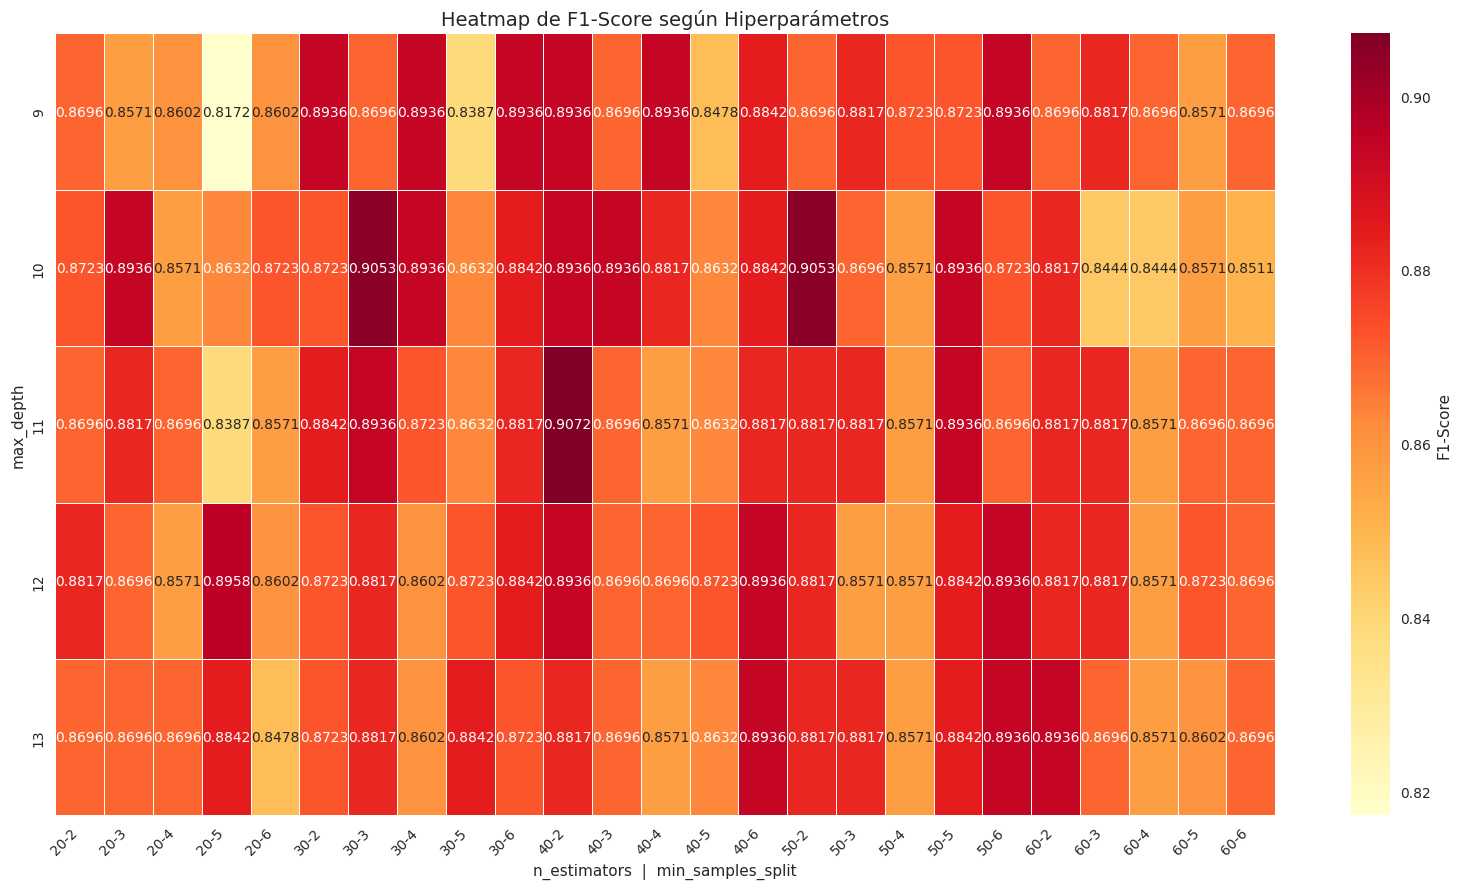

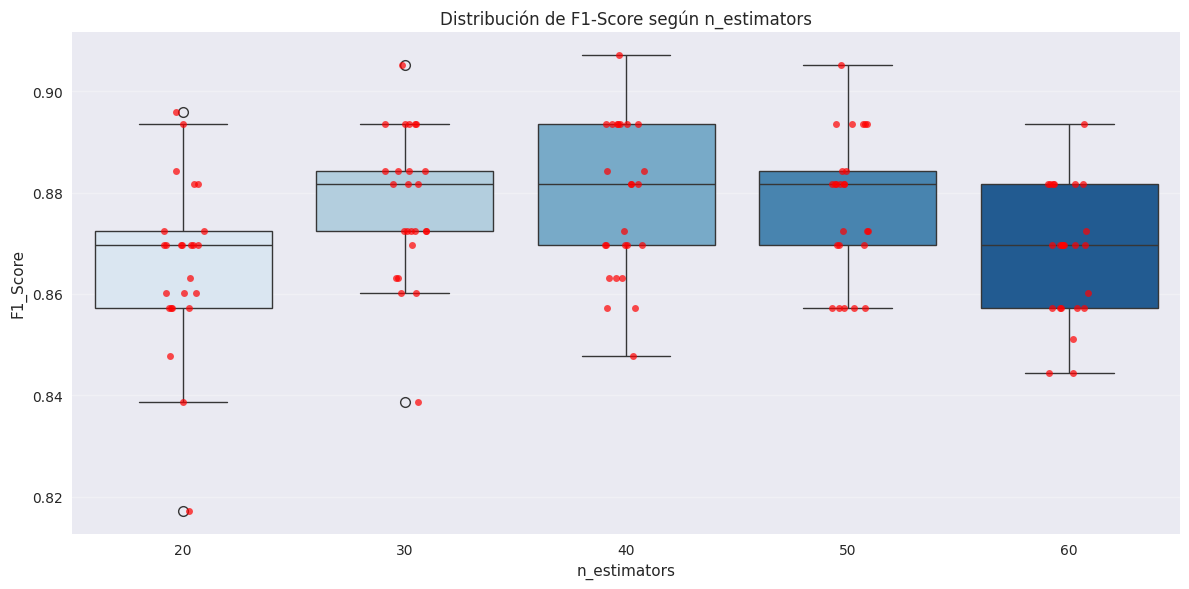

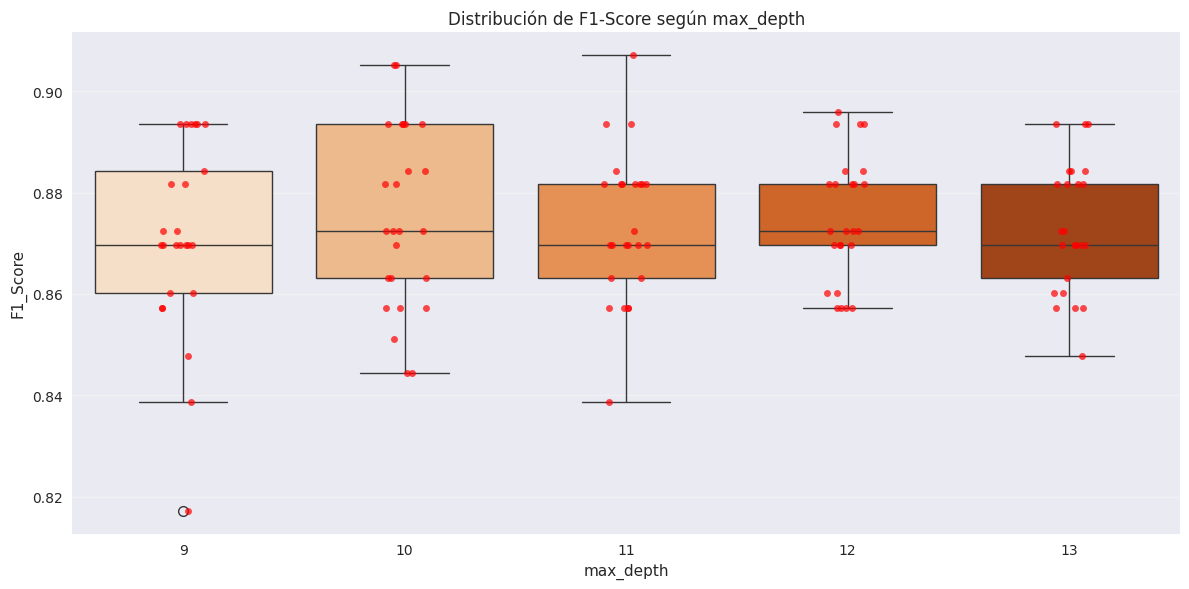

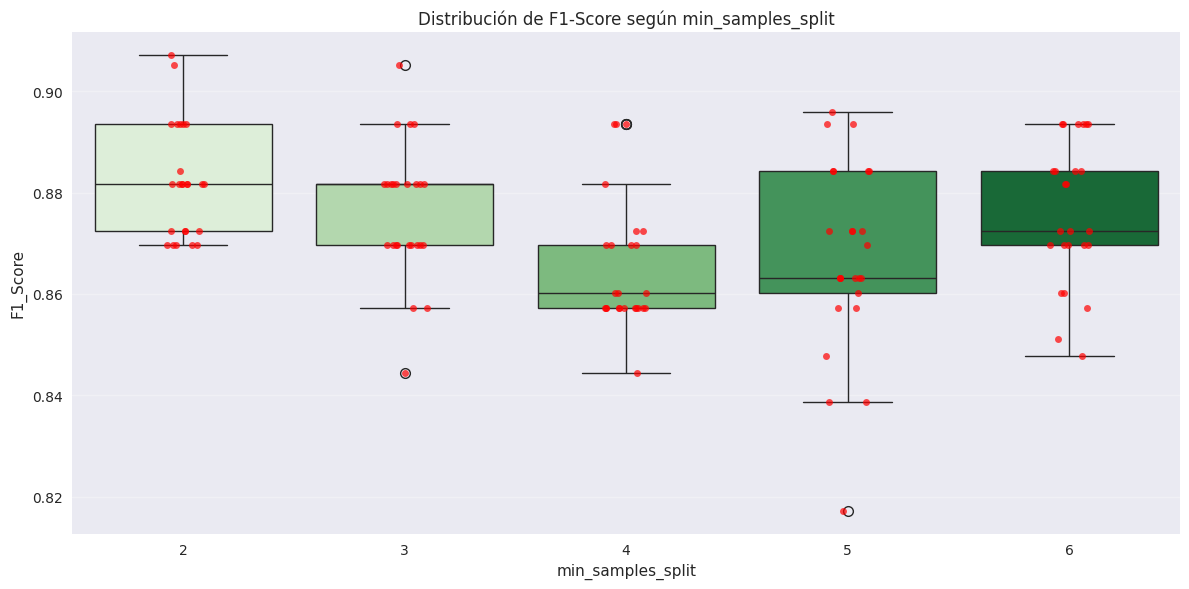


Todos los gráficos y tablas guardados en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2


In [7]:
# Convertir resultados del tuning a DataFrame
df_tuning = pd.DataFrame(all_tuning_results)

# TABLA COMPARATIVA DE TODAS LAS VARIANTES
print("\n" + "="*100)
print("TABLA COMPARATIVA DE TODAS LAS COMBINACIONES DEL TUNING")
print("="*100)

# Ordenar por F1-Score descendente
df_tuning_sorted = df_tuning.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# Mostrar tabla completa y bien formateada
print(df_tuning_sorted[['n_estimators', 'max_depth', 'min_samples_split', 
                       'F1_Score', 'PR_AUC', 'Tiempo(s)']].round(4))

# Guardar tabla completa
df_tuning_sorted.to_csv(f"{OUTPUT_DIR}/tuning.csv", index=False)
print(f"\nTabla completa guardada en: {OUTPUT_DIR}/tuning.csv")

# TABLA TOP 15
print("\n" + "="*80)
print("TOP 15 MEJORES COMBINACIONES")
print("="*80)
top15 = df_tuning_sorted.head(15)
print(top15[['n_estimators', 'max_depth', 'min_samples_split', 
             'F1_Score', 'PR_AUC', 'Tiempo(s)']].round(4))

# GRÁFICOS

# 1. Heatmap
plt.figure(figsize=(16, 9))
pivot = df_tuning.pivot_table(
    values='F1_Score', 
    index='max_depth', 
    columns=['n_estimators', 'min_samples_split'], 
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5, linecolor='white', 
            cbar_kws={'label': 'F1-Score'})
plt.title('Heatmap de F1-Score según Hiperparámetros', fontsize=14)
plt.xlabel('n_estimators  |  min_samples_split')
plt.ylabel('max_depth')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()

# 2. Distribución por n_estimators
plt.figure(figsize=(12, 6))
sns.boxplot(x='n_estimators', y='F1_Score', data=df_tuning, palette='Blues')
sns.stripplot(x='n_estimators', y='F1_Score', data=df_tuning, color='red', alpha=0.7, size=5)
plt.title('Distribución de F1-Score según n_estimators')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_n_estimators.png", dpi=100, bbox_inches='tight')
plt.show()

# 3. Distribución por max_depth
plt.figure(figsize=(12, 6))
sns.boxplot(x='max_depth', y='F1_Score', data=df_tuning, palette='Oranges')
sns.stripplot(x='max_depth', y='F1_Score', data=df_tuning, color='red', alpha=0.7, size=5)
plt.title('Distribución de F1-Score según max_depth')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_max_depth.png", dpi=100, bbox_inches='tight')
plt.show()

# 4. Distribución por min_samples_split
plt.figure(figsize=(12, 6))
sns.boxplot(x='min_samples_split', y='F1_Score', data=df_tuning, palette='Greens')
sns.stripplot(x='min_samples_split', y='F1_Score', data=df_tuning, color='red', alpha=0.7, size=5)
plt.title('Distribución de F1-Score según min_samples_split')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tuning_min_samples_split.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"\nTodos los gráficos y tablas guardados en: {OUTPUT_DIR}")

## Optuna XGBoost (Gradient Boosting)

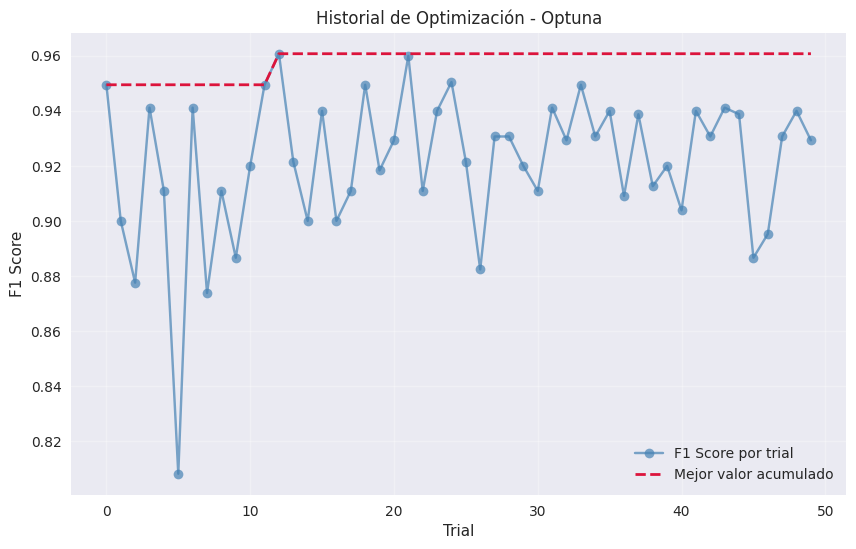

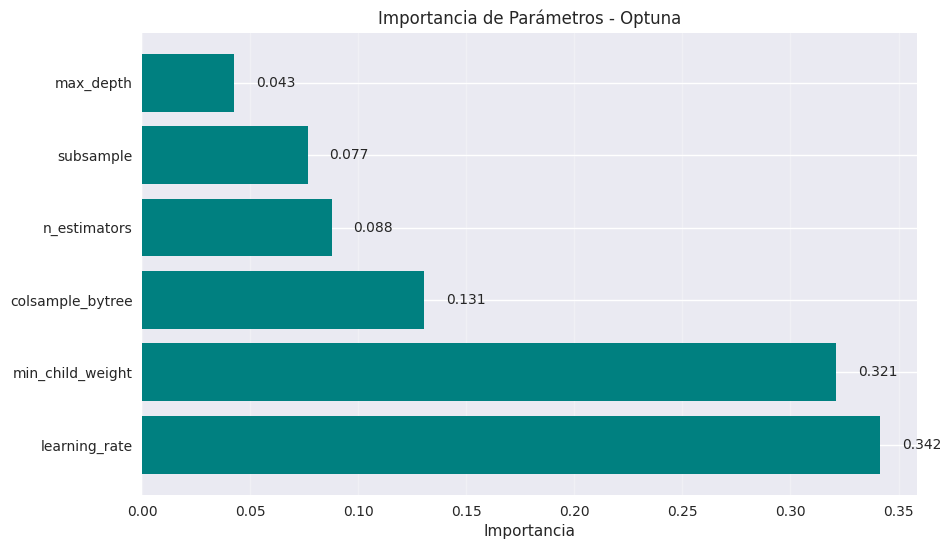

Gráficos Optuna guardados en outputs_sprint2/


In [8]:
trials_df = study.trials_dataframe()

plt.figure(figsize=(10, 6))
plt.plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-', 
         color='steelblue', alpha=0.7, label='F1 Score por trial')

# Línea del mejor valor encontrado hasta cada trial
best_so_far = trials_df['value'].cummax()
plt.plot(trials_df['number'], best_so_far, color='crimson', 
         linestyle='--', linewidth=2, label='Mejor valor acumulado')

plt.xlabel('Trial')
plt.ylabel('F1 Score')
plt.title('Historial de Optimización - Optuna')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/optuna_optimization_history.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

# 2. IMPORTANCIA DE PARÁMETROS
try:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    vals = list(importances.values())
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(params, vals, color='teal')
    plt.xlabel('Importancia')
    plt.title('Importancia de Parámetros - Optuna')
    plt.grid(axis='x', alpha=0.3)
    
    # Añadir valores en las barras
    for bar, val in zip(bars, vals):
        plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=10)
    
    plt.savefig(f"{OUTPUT_DIR}/optuna_param_importances.png", dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as e:
    print(f"No se pudo calcular importancia de parámetros: {e}")

# 3. SLICE PLOTS (uno por parámetro importante)
for param in ['n_estimators', 'max_depth', 'learning_rate', 
              'subsample', 'colsample_bytree', 'min_child_weight']:
    if param in trials_df.columns:
        plt.figure(figsize=(8, 5))
        scatter = plt.scatter(trials_df[param], trials_df['value'], 
                           c=trials_df['number'], cmap='viridis', alpha=0.7)
        plt.colorbar(scatter, label='Número de trial')
        plt.xlabel(param)
        plt.ylabel('F1 Score')
        plt.title(f'Slice Plot: {param}')
        plt.grid(True, alpha=0.3)
        plt.savefig(f"{OUTPUT_DIR}/optuna_slice_{param}.png", dpi=100, bbox_inches='tight')
        plt.show()
        plt.close()

print("Gráficos Optuna guardados en outputs_sprint2/")

## Tabla comparativa

In [9]:
df_comparacion = pd.DataFrame(resultados)

# Reordenar columnas para mejor lectura
df_comparacion = df_comparacion[['Experimento', 'PR_AUC', 'F1_Score', 'Tiempo(s)']]

# Mostrar tabla formateada
print(df_comparacion.round(4))

# Resaltar el mejor modelo
mejor = df_comparacion.loc[df_comparacion['F1_Score'].idxmax()]
print("\n" + "="*60)
print(f"MEJOR MODELO: {mejor['Experimento']}")
print(f"F1-Score: {mejor['F1_Score']:.4f} | PR-AUC: {mejor['PR_AUC']:.4f}")
print("="*60)

# Guardar tabla
df_comparacion.to_csv(f"{OUTPUT_DIR}/metrics_experimentos.csv", index=False)

print(f"\nTabla comparativa guardada en: {OUTPUT_DIR}/metrics_experimentos.csv")

             Experimento  PR_AUC  F1_Score  Tiempo(s)
0               Baseline  0.7182    0.6789       1.88
1          Baseline + FE  0.9792    0.8723       1.03
2            FE + Tuning  0.9757    0.9072       0.38
3  FE + Optuna (XGBoost)  0.9909    0.9608       0.58

MEJOR MODELO: FE + Optuna (XGBoost)
F1-Score: 0.9608 | PR-AUC: 0.9909

Tabla comparativa guardada en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2/metrics_experimentos.csv


## Validación cruzada

In [10]:
def evaluar_cross_validation(model, X, y, nombre, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scoring = ['f1', 'average_precision']
    
    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)
    
    print(f"\n{'='*80}")
    print(f"VALIDACIÓN CRUZADA (5-Fold) - {nombre}")
    print(f"{'='*80}")
    
    summary = {}
    for metric in ['test_f1', 'test_average_precision']:
        mean = cv_results[metric].mean()
        std = cv_results[metric].std()
        name_clean = metric.replace('test_', '').replace('average_precision', 'PR_AUC')
        print(f"{name_clean:12} → {mean:.4f} ± {std:.4f}")
        summary[name_clean] = {'mean': mean, 'std': std}
    
    return summary

models_cv = {
    'Baseline': model_base,
    'Baseline + FE': model_fe,
    'FE + Tuning': best_model,
    'FE + Optuna (XGBoost)': best_model_optuna
}

X_dict = {
    'Baseline': X_train_base,
    'Baseline + FE': X_train_fe,
    'FE + Tuning': X_train_fe,
    'FE + Optuna (XGBoost)': X_train_fe
}

print("\nEjecutando Validación Cruzada en los 4 modelos...")

metrics_cv = []
for name, model in models_cv.items():
    summary = evaluar_cross_validation(model, X_dict[name], y_train, name)
    metrics_cv.append({
        'Experimento': name,
        'F1_mean': summary['f1']['mean'],
        'F1_std': summary['f1']['std'],
        'PR_AUC_mean': summary['PR_AUC']['mean'],
        'PR_AUC_std': summary['PR_AUC']['std']
    })

df_cv = pd.DataFrame(metrics_cv)
print("\nRESUMEN VALIDACIÓN CRUZADA:")
print(df_cv.round(4))

df_cv.to_csv(f"{OUTPUT_DIR}/metrics_cross_validation.csv", index=False)
print(f"\nResultados CV guardados en: {OUTPUT_DIR}/metrics_cross_validation.csv")


Ejecutando Validación Cruzada en los 4 modelos...

VALIDACIÓN CRUZADA (5-Fold) - Baseline
f1           → 0.9645 ± 0.0084
PR_AUC       → 0.9956 ± 0.0021

VALIDACIÓN CRUZADA (5-Fold) - Baseline + FE
f1           → 0.9875 ± 0.0052
PR_AUC       → 0.9994 ± 0.0005

VALIDACIÓN CRUZADA (5-Fold) - FE + Tuning
f1           → 0.9865 ± 0.0052
PR_AUC       → 0.9992 ± 0.0007

VALIDACIÓN CRUZADA (5-Fold) - FE + Optuna (XGBoost)
f1           → 0.9879 ± 0.0073
PR_AUC       → 0.9996 ± 0.0003

RESUMEN VALIDACIÓN CRUZADA:
             Experimento  F1_mean  F1_std  PR_AUC_mean  PR_AUC_std
0               Baseline   0.9645  0.0084       0.9956      0.0021
1          Baseline + FE   0.9875  0.0052       0.9994      0.0005
2            FE + Tuning   0.9865  0.0052       0.9992      0.0007
3  FE + Optuna (XGBoost)   0.9879  0.0073       0.9996      0.0003

Resultados CV guardados en: /workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2/metrics_cross_validation.csv


## Graficos comparativos

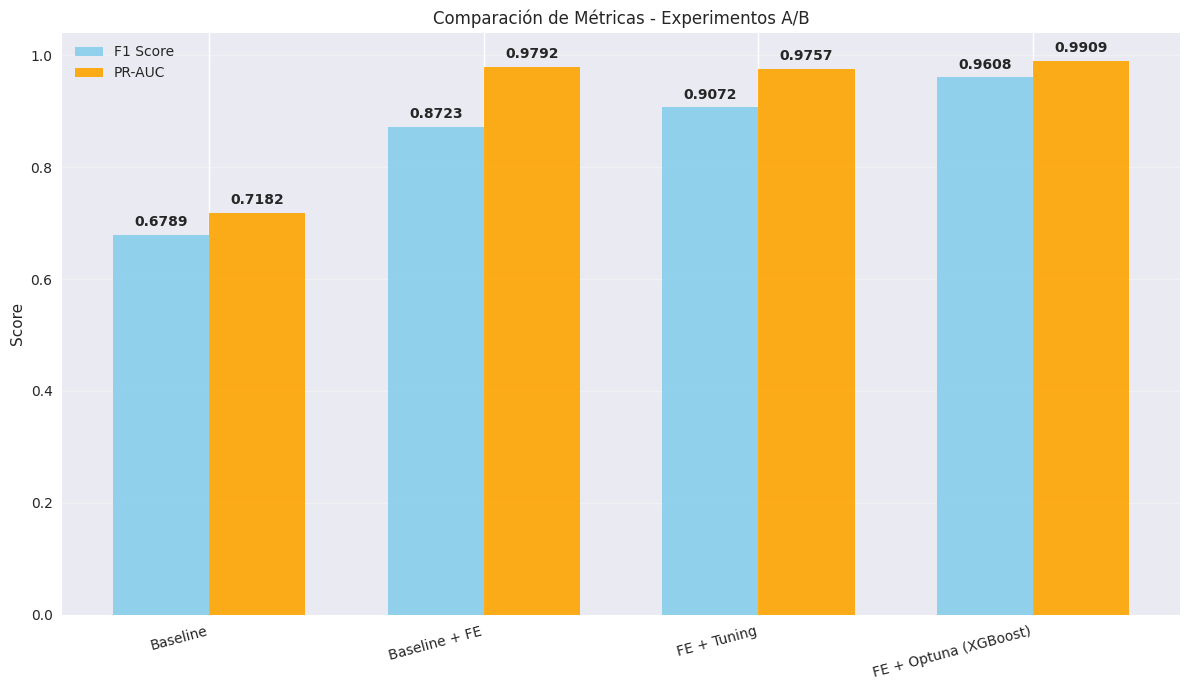

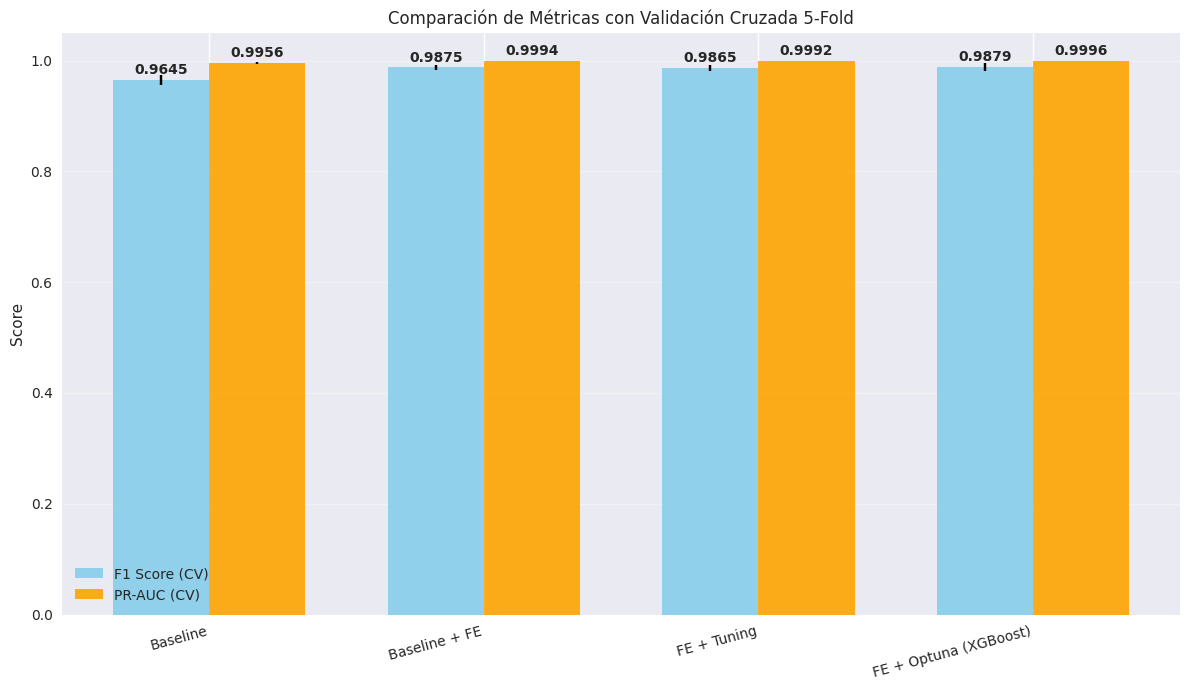

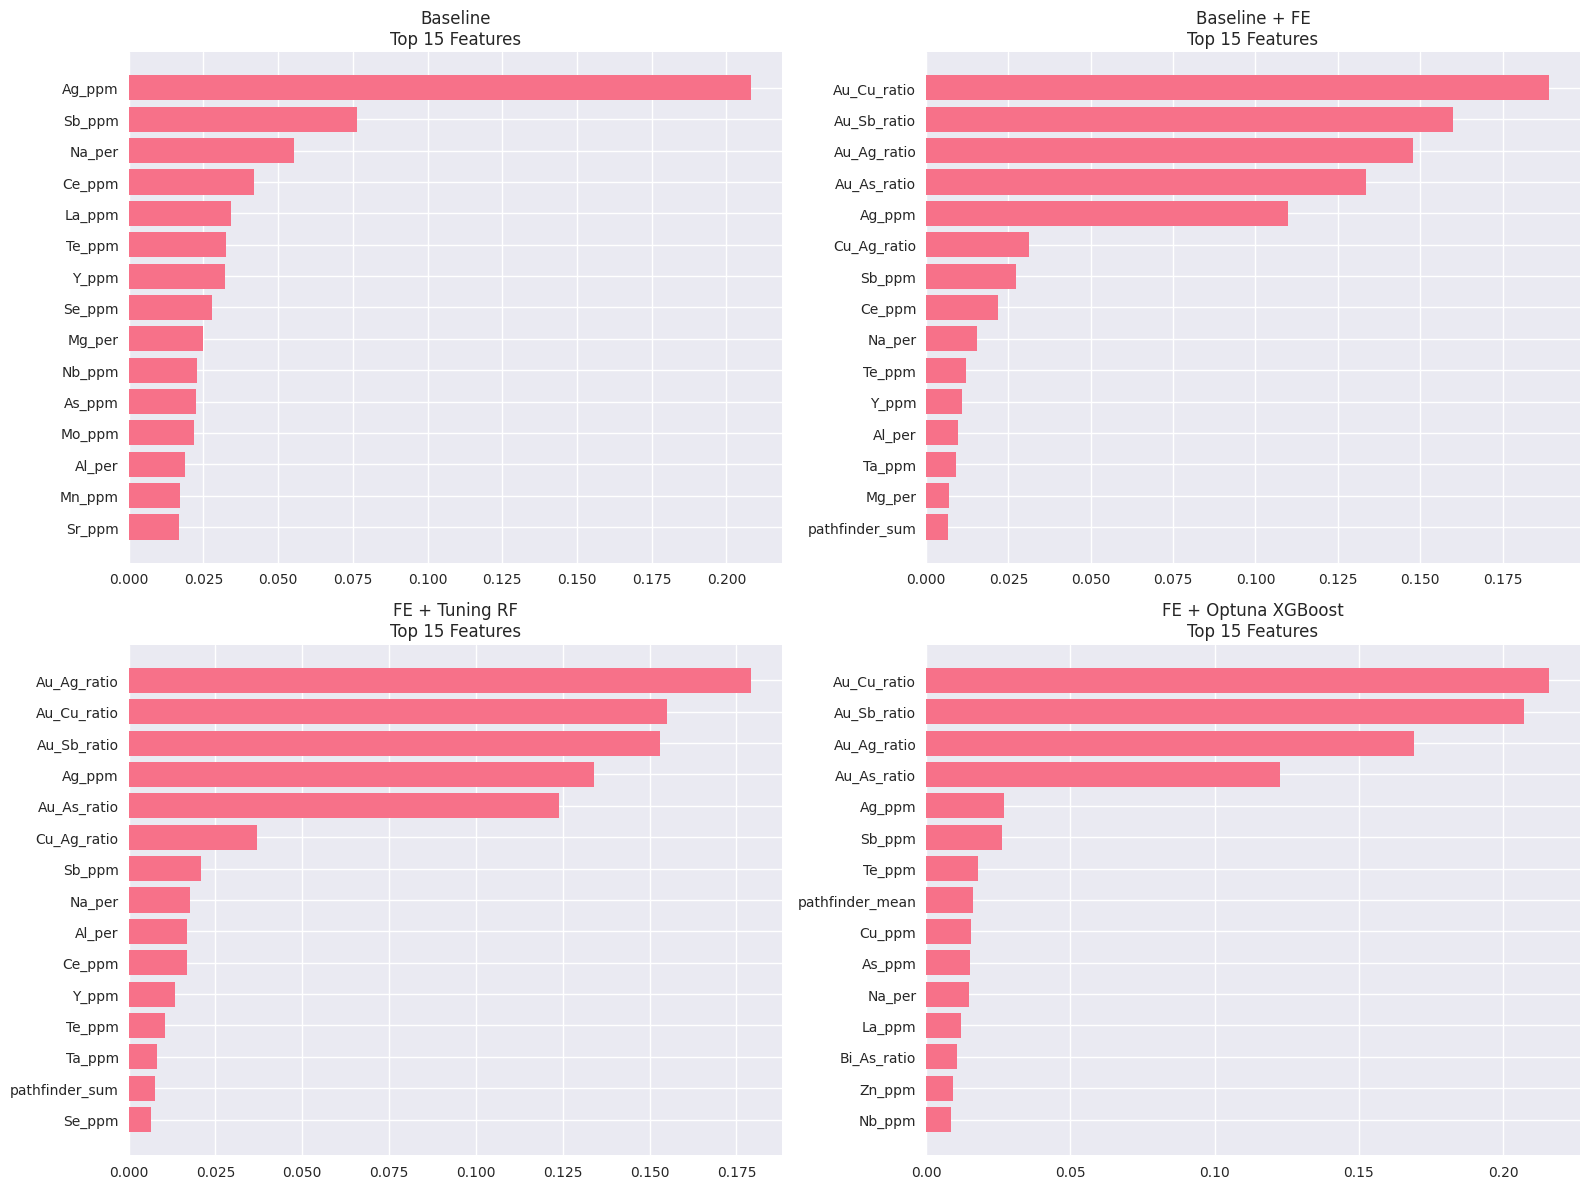

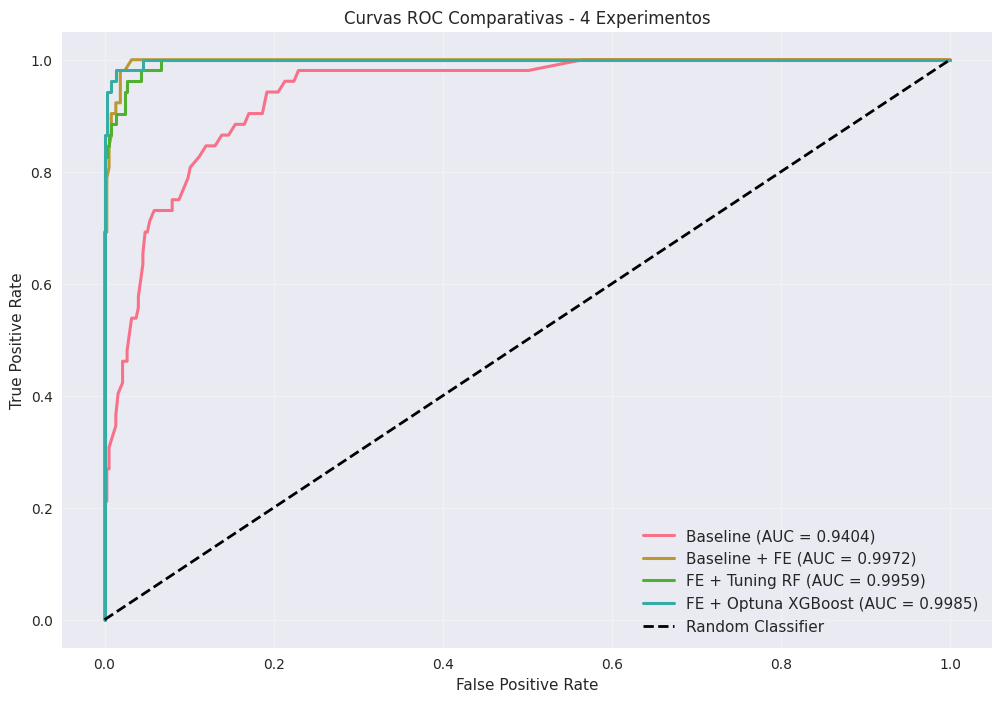

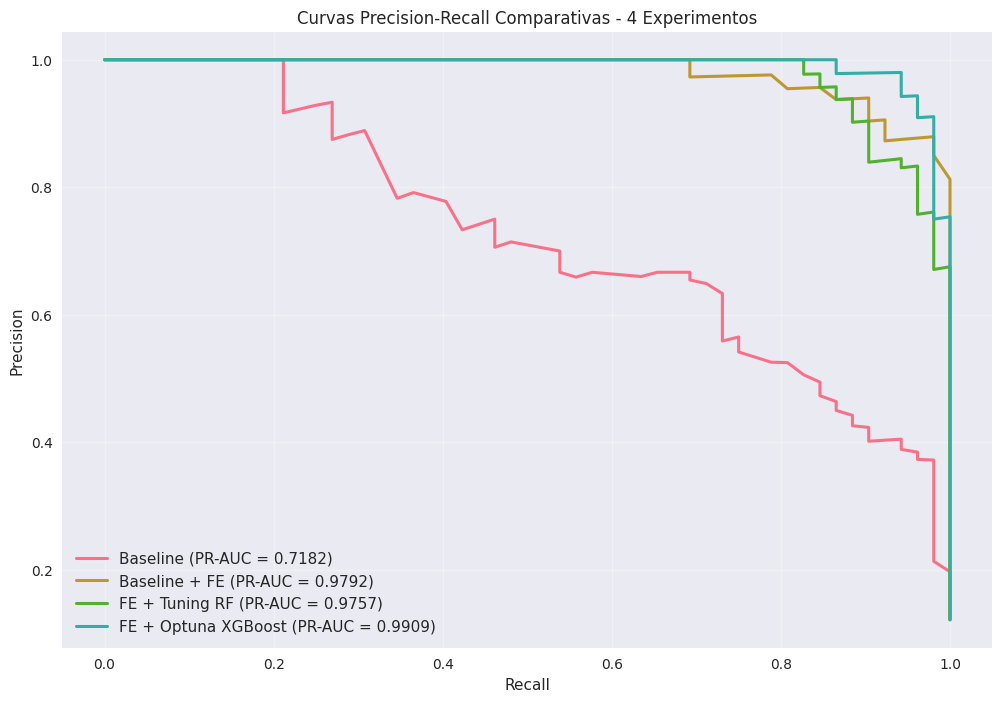

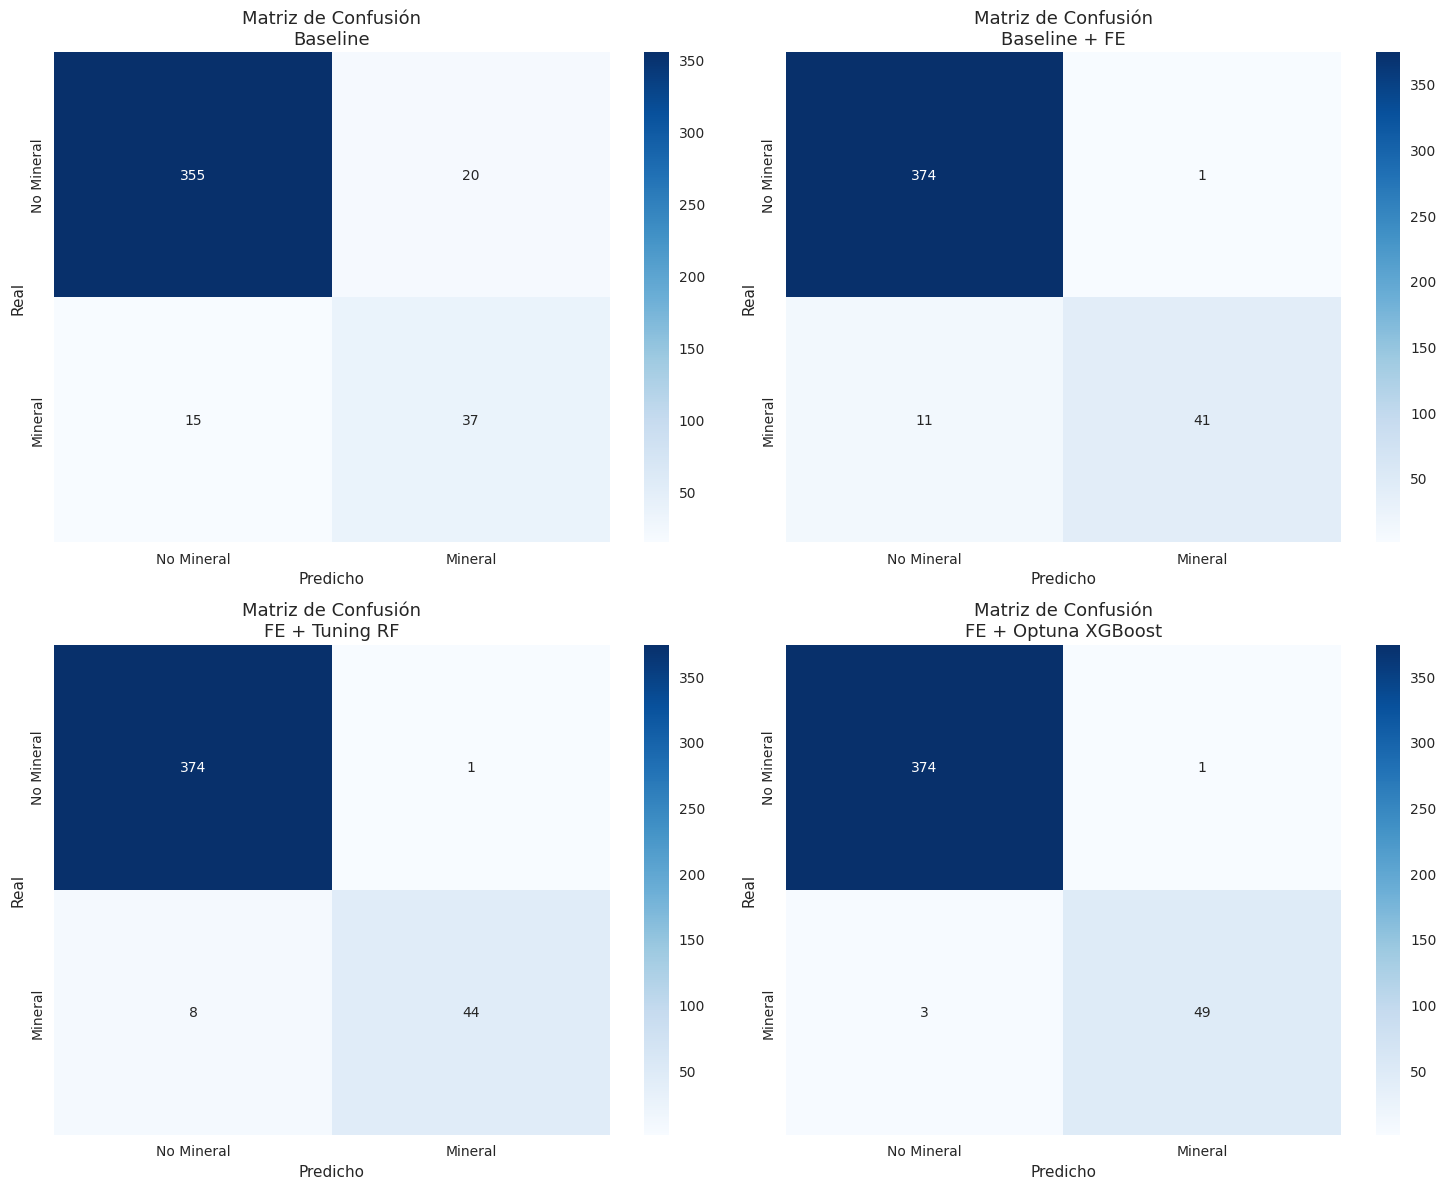


Todos los gráficos han sido guardados correctamente en:
/workspaces/proyecto-zona-interes-Au/notebooks/outputs_sprint2


In [11]:
# 1. Comparación de Métricas
df_comp = pd.DataFrame(resultados)
plt.figure(figsize=(12, 7))
x = np.arange(len(df_comp))
width = 0.35

bars1 = plt.bar(x - width/2, df_comp['F1_Score'], width, label='F1 Score', color='skyblue', alpha=0.9)
bars2 = plt.bar(x + width/2, df_comp['PR_AUC'], width, label='PR-AUC', color='orange', alpha=0.9)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.4f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(x, df_comp['Experimento'], rotation=15, ha='right')
plt.ylabel('Score')
plt.title('Comparación de Métricas - Experimentos A/B')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_comparacion.png", dpi=100, bbox_inches='tight')
plt.show()

# 2. Comparación de Métricas con CV
# Preparar datos
x = np.arange(len(df_cv))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Barras agrupadas con barras de error
bars1 = ax.bar(x - width/2, df_cv['F1_mean'], width, 
               yerr=df_cv['F1_std'], capsize=6, 
               label='F1 Score (CV)', color='skyblue', alpha=0.9)

bars2 = ax.bar(x + width/2, df_cv['PR_AUC_mean'], width, 
               yerr=df_cv['PR_AUC_std'], capsize=6, 
               label='PR-AUC (CV)', color='orange', alpha=0.9)

# Etiquetas de valores encima de las barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005, 
            f'{height:.4f}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005, 
            f'{height:.4f}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

# Configuración visual
ax.set_xticks(x)
ax.set_xticklabels(df_cv['Experimento'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas con Validación Cruzada 5-Fold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/comparacion_cv_variabilidad.png", dpi=100, bbox_inches='tight')
plt.show()

# 3. Feature Importance Comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

models_fi = {
    'Baseline': (model_base, features_base, 'Baseline'),
    'Baseline + FE': (model_fe, features_fe, 'Baseline + FE'),
    'FE + Tuning RF': (best_model, features_fe, 'FE + Tuning RF'),
    'FE + Optuna XGBoost': (best_model_optuna, features_fe, 'FE + Optuna XGBoost')
}

for i, (name, (model, features, title)) in enumerate(models_fi.items()):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-15:]  # Top 15 features
    
    axes[i].barh(range(15), importances[indices])
    axes[i].set_yticks(range(15))
    axes[i].set_yticklabels([features[j] for j in indices])
    axes[i].set_title(f'{title}\nTop 15 Features')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_Importancia.png", dpi=100, bbox_inches='tight')
plt.show()

# 4. Curvas ROC
plt.figure(figsize=(12, 8))

# Diccionario con los modelos y sus probabilidades
roc_data = {
    'Baseline': y_proba_base,
    'Baseline + FE': y_proba_fe,
    'FE + Tuning RF': y_proba_best,
    'FE + Optuna XGBoost': y_prob_optuna
}

for name, y_proba in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Comparativas - 4 Experimentos')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/FE_curves_roc.png", dpi=100, bbox_inches='tight')
plt.show()

# 5. Curvas Precision-Recall
plt.figure(figsize=(12, 8))

for name, y_proba in roc_data.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, lw=2.2, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall Comparativas - 4 Experimentos')
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/FE_curves_precision_recall.png", dpi=100, bbox_inches='tight')
plt.show()

# 6. Matrices de Confusión
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

conf_data = {
    'Baseline': (model_base, X_test_base),
    'Baseline + FE': (model_fe, X_test_fe),
    'FE + Tuning RF': (best_model, X_test_fe),
    'FE + Optuna XGBoost': (best_model_optuna, X_test_fe)
}

for i, (name, (model, X_test)) in enumerate(conf_data.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Mineral', 'Mineral'], 
                yticklabels=['No Mineral', 'Mineral'])
    axes[i].set_title(f'Matriz de Confusión\n{name}', fontsize=13)
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/FE_matrices_confusion.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTodos los gráficos han sido guardados correctamente en:\n{OUTPUT_DIR}")

# SHAP, Learning Curves y Calibración

## Importar librerias

In [12]:
import shap
from sklearn.model_selection import LearningCurveDisplay, StratifiedKFold
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas")

Librerías cargadas


## Seleccion de Features

In [13]:
print("=== ANÁLISIS DE IMPORTANCIA DE FEATURES ===")

# Usamos el mejor modelo (FE + Optuna XGBoost)
best_model = best_model_optuna

# 1. Importancia por Gain (RandomForest)
importancias = pd.Series(best_model.feature_importances_, 
                        index=X_train_fe.columns).sort_values(ascending=False)

print("Top 15 Features más importantes:")
print(importancias.head(15))

# Guardar
importancias.to_csv(f"{OUTPUT_DIR}/feature_importance.csv")

=== ANÁLISIS DE IMPORTANCIA DE FEATURES ===
Top 15 Features más importantes:
Au_Cu_ratio        0.215799
Au_Sb_ratio        0.207128
Au_Ag_ratio        0.169104
Au_As_ratio        0.122568
Ag_ppm             0.027087
Sb_ppm             0.026243
Te_ppm             0.018077
pathfinder_mean    0.016240
Cu_ppm             0.015654
As_ppm             0.015105
Na_per             0.014990
La_ppm             0.012078
Bi_As_ratio        0.010814
Zn_ppm             0.009455
Nb_ppm             0.008775
dtype: float32


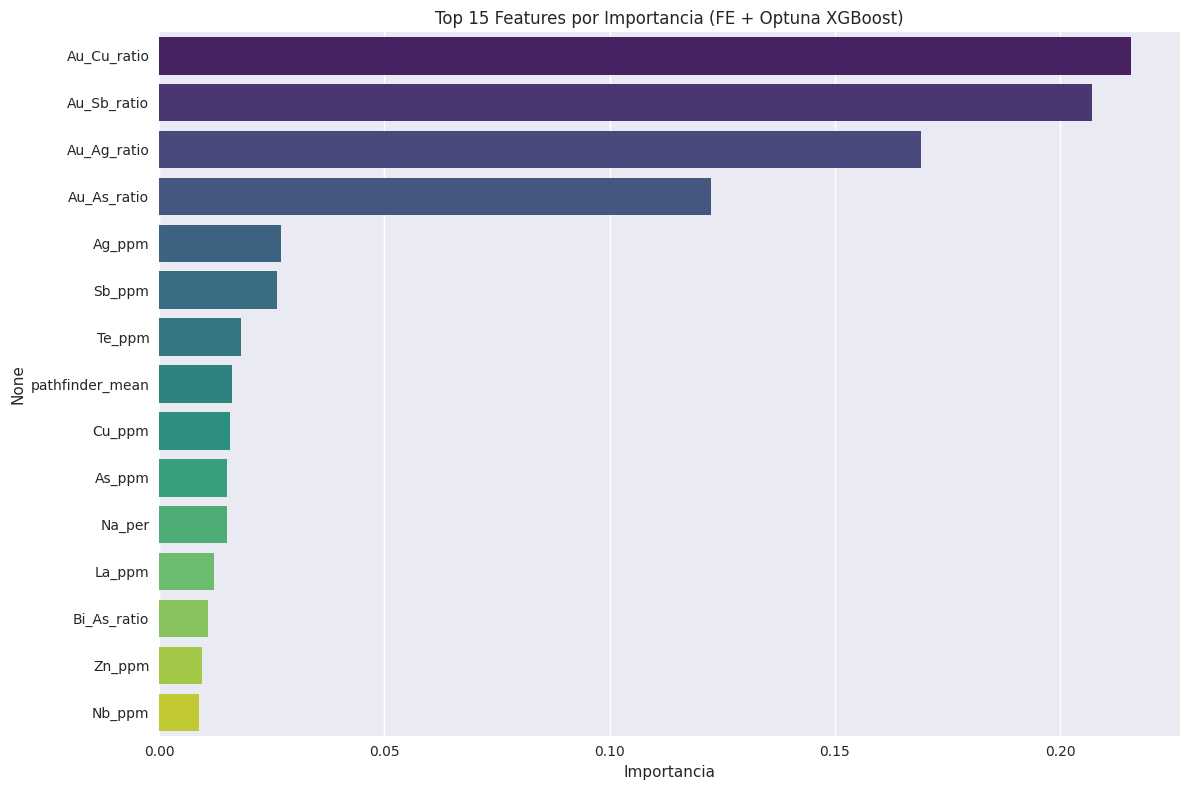

In [14]:
# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x=importancias.head(15).values, y=importancias.head(15).index, palette='viridis')
plt.title('Top 15 Features por Importancia (FE + Optuna XGBoost)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance_top15.png", dpi=100, bbox_inches='tight')
plt.show()

## Análisis SHAP

Calculando valores SHAP...
Tipo de shap_values: <class 'numpy.ndarray'>
Shape original: (427, 57)


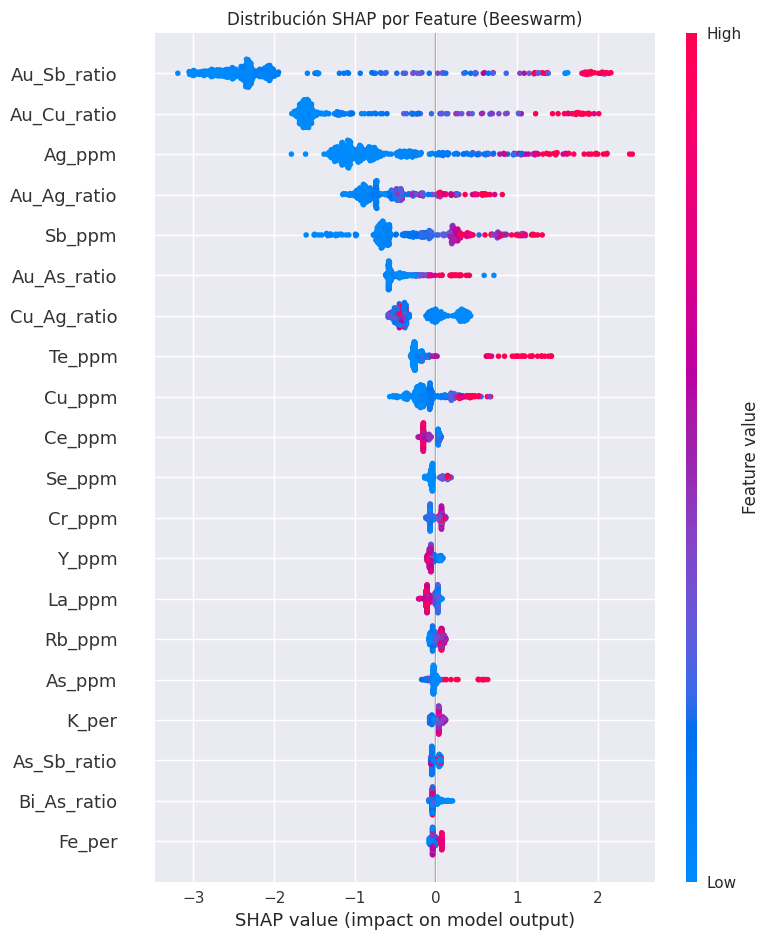

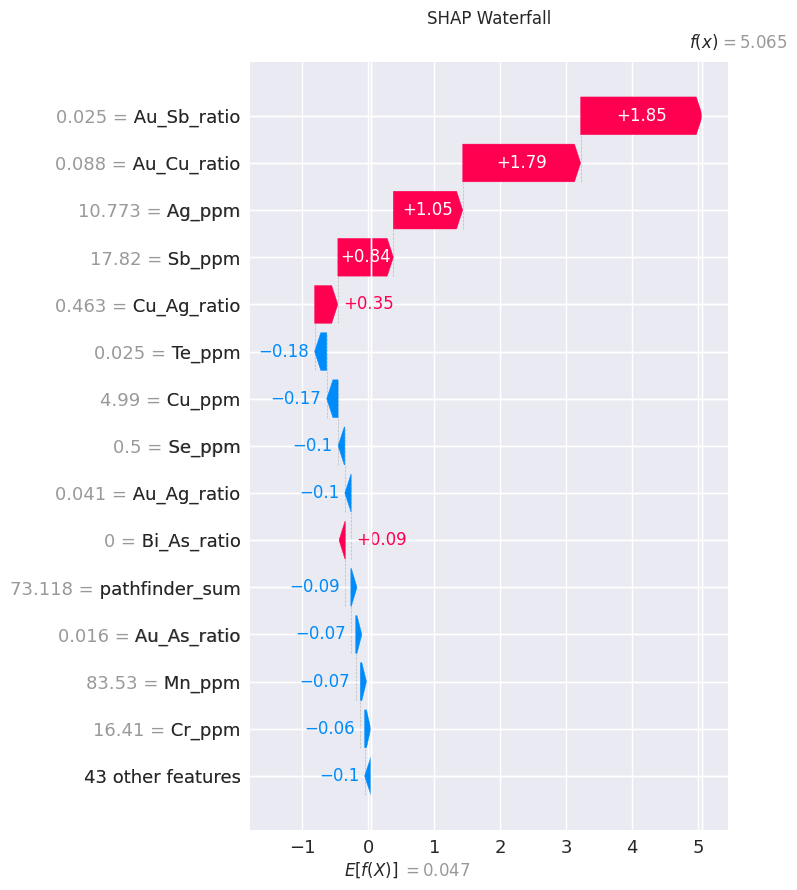

In [15]:
print("Calculando valores SHAP...")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_fe)

print(f"Tipo de shap_values: {type(shap_values)}")
print(f"Shape original: {np.asarray(shap_values).shape}")

if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
elif len(np.asarray(shap_values).shape) == 3:
    shap_values_to_use = shap_values[:, :, 1]
else:
    shap_values_to_use = shap_values

# 1. Summary Plot - Beeswarm
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_to_use, X_test_fe, show=False)
plt.title("Distribución SHAP por Feature (Beeswarm)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_summary_beeswarm.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

# 2. Waterfall
plt.figure(figsize=(12, 8))
explanation = shap.Explanation(
    values=shap_values_to_use[0],
    base_values=explainer.expected_value[1] 
                if hasattr(explainer, 'expected_value') and isinstance(explainer.expected_value, (list, np.ndarray)) 
                else explainer.expected_value,
    data=X_test_fe.iloc[0:1].values[0],
    feature_names=X_test_fe.columns.tolist()
)

shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title("SHAP Waterfall")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_waterfall_example.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

## Curvas de Aprendizaje

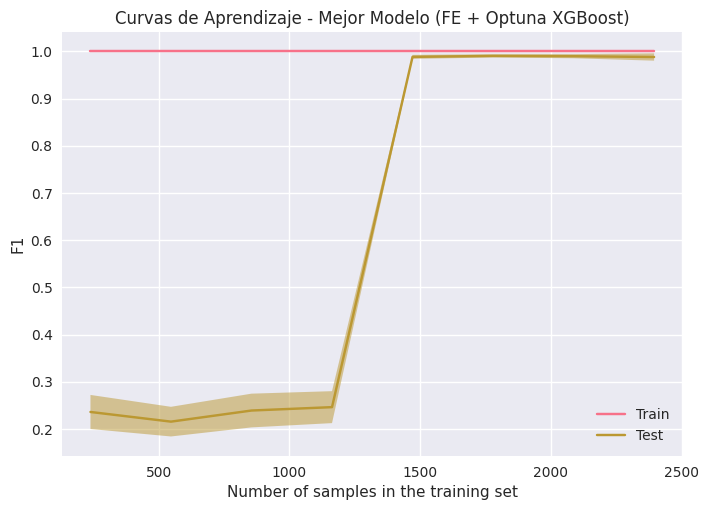

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

LearningCurveDisplay.from_estimator(
    best_model, 
    X_train_fe, 
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    score_type='both'
)

plt.title('Curvas de Aprendizaje - Mejor Modelo (FE + Optuna XGBoost)')
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/learning_curves.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

## Calibración del Modelo

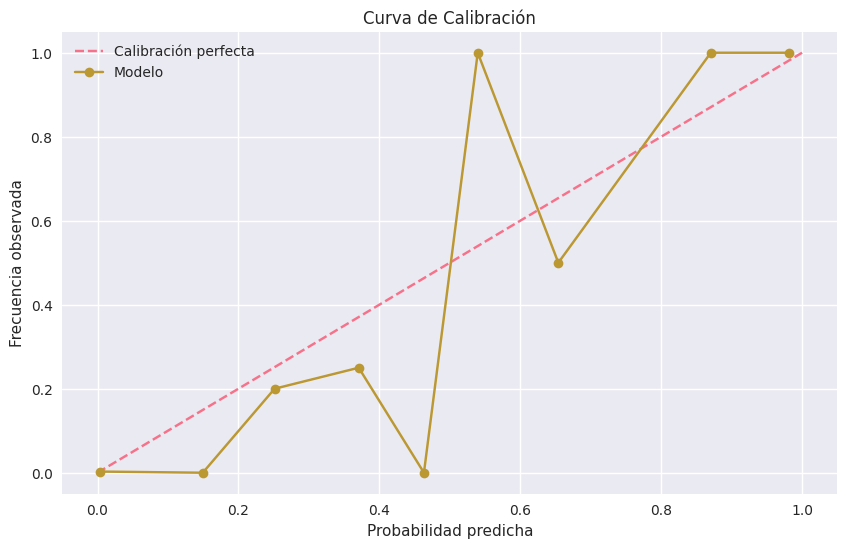

Brier Score: 0.0099 (más bajo = mejor calibrado)


In [17]:
y_prob = best_model.predict_proba(X_test_fe)[:, 1]

# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Calibración perfecta')
plt.plot(prob_pred, prob_true, marker='o', label='Modelo')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia observada')
plt.title('Curva de Calibración')
plt.legend()
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}/calibration_curve.png", dpi=100, bbox_inches='tight')
plt.show()
plt.close()

# Brier Score
brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier:.4f} (más bajo = mejor calibrado)")